# K-Means Clustering (PCA 2D Visualization)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import cv2
import os

In [37]:
# Load pretrained model using VGG16 Model
base_model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=base_model.input, outputs=base_model.output)

In [38]:
# Load dataset 
dataset_path = "crab-images-dataset/test"
image_size = (128, 128)  # Image input size
images = []
image_names = []
original_labels = []

# Loop each folder and normalize for VGG16
for crab_type in os.listdir(dataset_path):
    crab_folder = os.path.join(dataset_path, crab_type)

    if os.path.isdir(crab_folder):
        for filename in os.listdir(crab_folder):
            img_path = os.path.join(crab_folder, filename)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.resize(img, image_size)
                img = preprocess_input(img)
                images.append(img)
                image_names.append(filename)
                original_labels.append(crab_type)

In [39]:
images = np.array(images)

In [40]:
# Extract Features using VGG16
features = model.predict(images)
features = features.reshape(len(images), -1)  # Flatten image


43/43 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step


In [41]:
# Reduce Dimensions with PCA
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

In [42]:
# Apply K-Means Clustering
k = 5  # 5 crustacean species
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features_pca)

In [43]:
# Compare predicted clusters with original labels
cluster_mapping = {i: [] for i in range(k)}
for i, cluster in enumerate(clusters):
    cluster_mapping[cluster].append(original_labels[i])

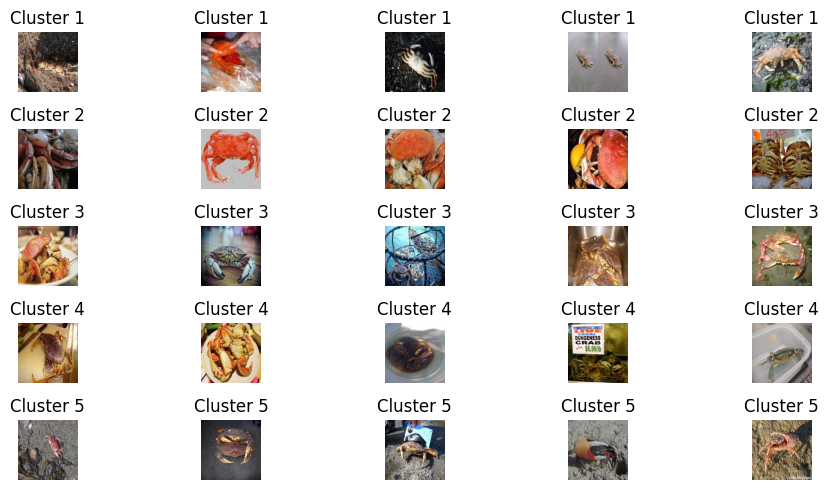

In [44]:
# Display sample images from clusters (5 samples per cluster)
plt.figure(figsize=(10, 5))
for i in range(k):
    cluster_images = np.where(clusters == i)[0][:5]
    
    for j, img_idx in enumerate(cluster_images):
        img = cv2.imread(os.path.join(dataset_path, original_labels[img_idx], image_names[img_idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(k, 5, i * 5 + j + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Cluster {i+1}")

plt.tight_layout()
plt.show()

In [45]:
for cluster, species in cluster_mapping.items():
    print(f"Cluster {cluster}: {set(species)}")

Cluster 0: {'king_crab', 'rock_crab', 'dungeness_crab', 'fiddler_crab', 'hermit_crab'}
Cluster 1: {'king_crab', 'hermit_crab', 'dungeness_crab', 'rock_crab'}
Cluster 2: {'king_crab', 'rock_crab', 'dungeness_crab', 'fiddler_crab', 'hermit_crab'}
Cluster 3: {'king_crab', 'rock_crab', 'dungeness_crab', 'fiddler_crab', 'hermit_crab'}
Cluster 4: {'king_crab', 'rock_crab', 'dungeness_crab', 'fiddler_crab', 'hermit_crab'}


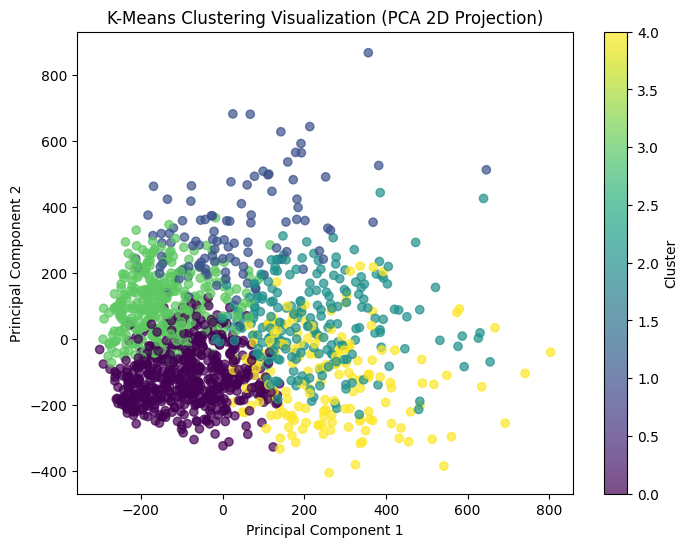

In [54]:
# Reduce dimensions to 2D for visualization
pca_2d = PCA(n_components=2)
features_2d = pca_2d.fit_transform(features_pca)  # Use PCA

# Display cluster using scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization (PCA 2D Projection)")

# Save figure
plt.savefig("k-means_clustering_PCA")
plt.show()